#### Case : Isobaric evaporation of liquid hydrogen in a 56 $m^3$ spherical tank experiments.

Este notebook modela el estanque de nueva generación de Air Liquide "SR 57 LH2", el camion de mayor capacidad para transporte de Hidrógeno en Europa. 
El estanque cuenta con una capacidad de 56 m3. Sus dimensiones son: 
Largo: 13,47m
Diametro interno: 2.3m
Diametro externo: 2.5m

En este Notebook se muestran los resultados para un nivel de llenado muy bajo, de 20% del volumen total.


Primero, importamos las librerías necesarias para el Notebook

In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

from scipy.integrate import simpson

#### Setup del estanque

Ingresamos los parámetros del modelo, incluyendo las dimensiones del estanque.

In [ ]:
# LNG tank properties
d_i = 2.3 # Internal diameter / m
d_o = d_i + 0.02   # External diameter / m
T_air = 298 # Temperature of the environment K

# Set overall heat transfer coefficient through the walls for liquid and vapour
# Se mantiene el U seleccionado para LF = 0.8.
U_L = 0.0045 #W/M2 K
U_V = 0.0045
eta = 0.9

# Specify heat transfer rate at the bottom to prevent ground heating
Q_b = 0 # W, 
Q_roof = 0

# Spherical tank volume
V_tank      = 56 # m^3
Lenght_tank = 13.478 # m, length of the tank

# Initial liquid filling / Dimensionless
LF = 0.2

# Specify tank operating pressure
P = 500e3 # Pa

# Tank geometry (select between cylindrical, spherical or horizontal)

Geo_v1 = "horizontal"
Geo_l1 = "horizontal"


# Initialize large-scale tank
hor_tank = Tank(d_i, d_o, V_tank, Geo_v1, Geo_l1, LF, Lenght_tank)
hor_tank.set_HeatTransProps(U_L, U_V, T_air, Q_b, Q_roof, eta)
# Initialise cryogen
hydrogen1 = Cryogen(name = "hydrogen")
hydrogen1.set_coolprops(P)


# Set cryogen
hor_tank.cryogen = hydrogen1




Calculamos evaporación inicial y tiempo de periodo transiente.

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + hydrogen1.name + " is %.1e kg/h" % (hor_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % hor_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h1 = (np.floor(hor_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h1 )

# Calculate boil-off rate
BOR1 = (hor_tank.b_l_dot * 24 * 3600) / (hor_tank.V * hor_tank.LF * hor_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR1 * 100))

The initial evaporation rate of hydrogen is 1.2e+00 kg/h
Transient period = 865205.317 s 
Simulation time: 241 h
BOR = 4.128 %


Vemos que el BOR es 4 veces mayor que en el caso con LF = 0.8

#### Ejecución

Ejecutamos el modelo

In [4]:
# Define vertical spacing
dz = 0.0075*2

# Calculate number of nodes
n_z = 1 + int(np.round(hor_tank.l_V/dz, 0))

# Define dimensionless computational grid
hor_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
hor_tank.U_roof = 0

# Define evaporation time as twice as the transient period
evap_time = 3600 *tau_h1*2



# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
hor_tank.time_interval = 60

# Time step to plot each vapour temperature profile
hor_tank.plot_interval = evap_time/6

# Simulate the evaporation
hor_tank.evaporate(evap_time)

#### Resultados

#### Perfil de temperatura de la zona vapor

Visualizamos el perfil de temperatura para el vapor, tomando el largo adimensional. 

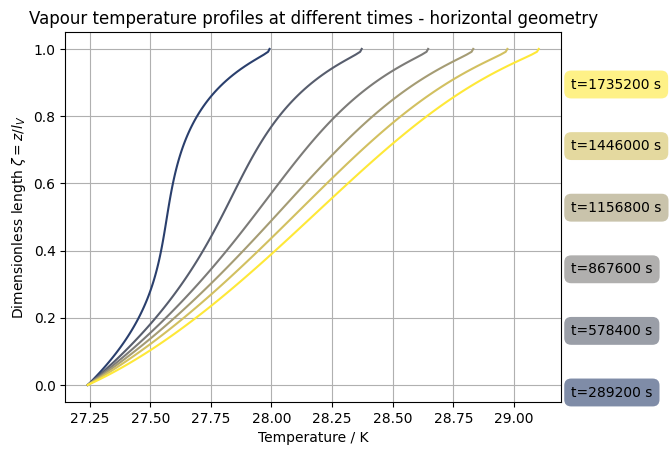

In [5]:
# Visualise the plot
hor_tank.plot_tv()

El comportamiento es similar al caso con nivel de llenado alto, sin embargo podemos notar que la estratificación térmica es mucho más grande. En este caso llega a ser de casi 2 grados, contra 0,8 del caso con nivel de llenado alto. 

#### Gráfico del área de la interfase

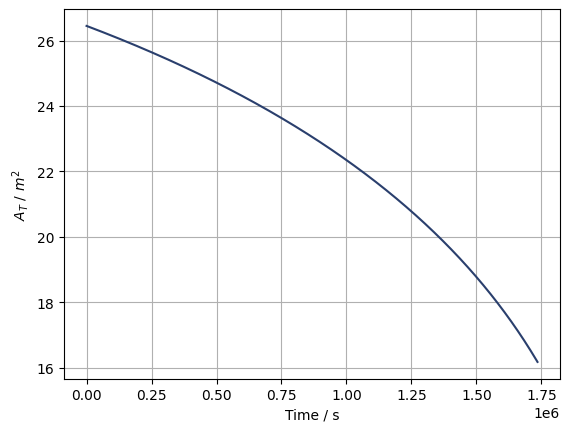

In [6]:
hor_tank.plot_A_T()

En este caso el área transversal va disminuyendo a lo largo del tiempo, ya que al encontrarse en la mitad inferior del cilindro, el área va disminuyendo a medida que baja la altura. 

#### Gráfico de velocidad del vapor

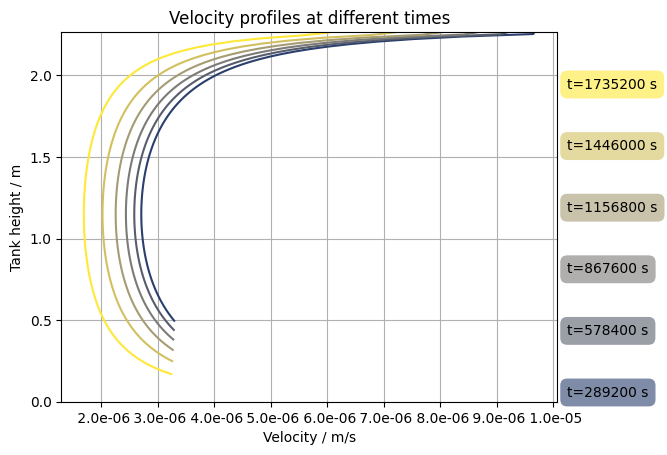

In [7]:
hor_tank.plot_vz_h()

Vemos que el comportamiento es correcto fisicamente, ya que la velocidad en todos los casos es mínima cuando la altura corresponde al radio del estanque. En ese punto, el área transversal es máxima, por lo que la velocidad del vapor es mínima.

#### Visualización de ingresos de calor, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

Ademas, se presenta el calor traspasado desde el vapor hacia el líquido por conducción, $\dot{Q}_{VL}$, y el calor total que ingresa al sistema, $\dot{Q}_{\text{tot}}$

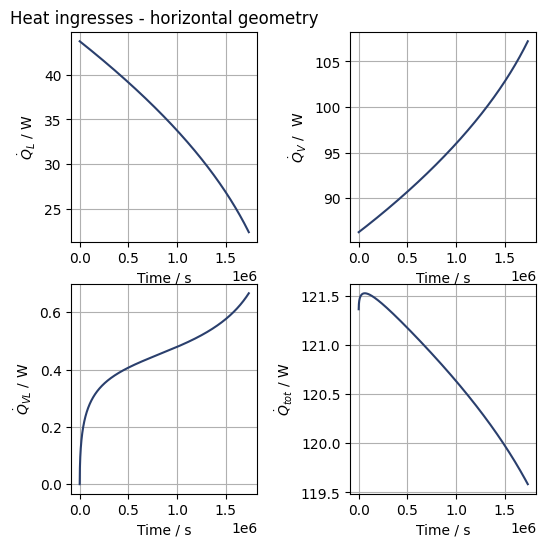

In [8]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
hor_tank.plot_Q(unit="W")

Vemos que el calor que ingresa al líquido va disminuyendo con el tiempo, mientras que el valor que pasa al vapor aumenta. Esto se debe a que las paredes mojadas de líquido disminuyen a lo largo del tiempo debido a la evaporación. Esto provoca una disminución en el calor que ingresa al liquido por las paredes. Caso contrario ocurre con el vapor. 

#### Volumen del líquido

Se presenta el volumen del líquido a lo largo del tiempo. Vemos que como hay evaporación, el volumen disminuye.

Resulta importante destacar que el volumen del líquido disminuye aproximadamente en un 80% de su valor inicial. Se pierde muchisimo líquido a lo largo del tiempo

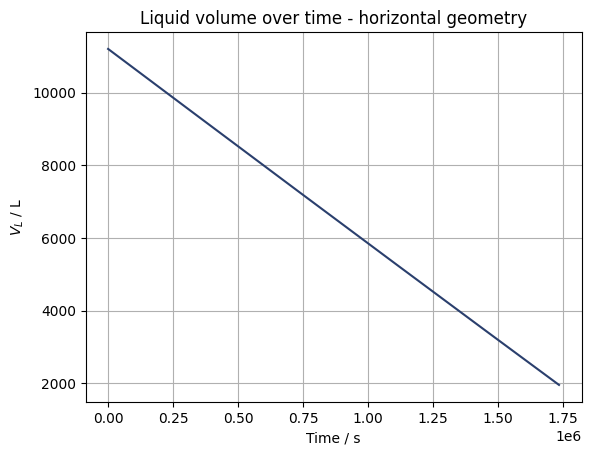

In [9]:

hor_tank.plot_V_L(unit="L")

#### Evaporation rate y BOG

Por último, se presenta la tasa de evaporación y el BOG a lo largo del tiempo.

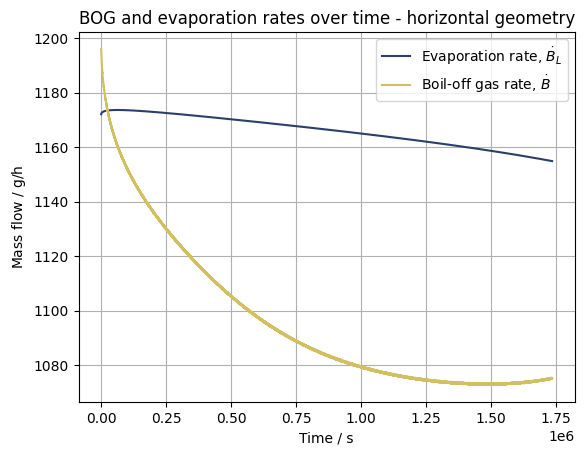

In [10]:

hor_tank.plot_BOG(unit='g/h')

Vemos que la tasa de evaporación se comporta de manera aproximadamente constante a lo largo del tiempo. Este comportamiento es similar a lo visto en el caso con LF = 0.8.

#### Cálculo de eficiencia energética

Para este almacenamiento, se calculan dos eficiencias distintas. 
La primera, se define como la división entre la masa de líquido final y la masa de líquido inicial. Esto corresponde a todo lo que no se evaporó a lo largo del tiempo.

Por otro lado, la segunda eficiencia se define como tódo el hidrógeno que sigue en el estanque, ya sea en fase líquida o en fase vapor. Esto es útil en casos en los que se tiene un mecanismo de condensación del vapor presente en el estanque. 

A continuación se presentan ambas eficiencias. 

Eficiencia 1 (solo líquido) al final: 17.43 %
Eficiencia 2 (L + V) al final:        44.55 %


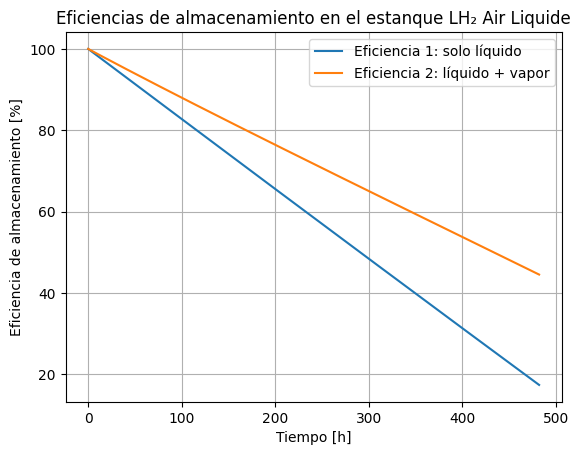

In [11]:
t = np.array(hor_tank.data['Time'])        # [s]
V_L = np.array(hor_tank.data['V_L'])       # [m^3] volumen líquido
rho_L = hor_tank.cryogen.rho_L             # [kg/m^3] densidad líquida (prácticamente constante)

V_tank = hor_tank.V                        # [m^3] volumen total del estanque
V_V = V_tank - V_L                         # [m^3] volumen vapor
rho_V = np.array(hor_tank.data['rho_V_avg'])  # [kg/m^3] densidad promedio del vapor

# --- Masas en función del tiempo ---
m_L = rho_L * V_L              # [kg] masa de líquido
m_V = rho_V * V_V              # [kg] masa de vapor

m_L0 = m_L[0]                  # masa inicial de líquido
m_V0 = m_V[0]
m_tot0 = m_L0 + m_V0

# --- Eficiencia 1: solo líquido 
eta1 = m_L / m_L0              # fracción
eta1_pct = eta1 * 100          # [%]

# --- Eficiencia 2: líquido + vapor 
eta2 = (m_L + m_V) / m_tot0      # fracción
eta2_pct = eta2 * 100          # [%]

print(f"Eficiencia 1 (solo líquido) al final: {eta1_pct[-1]:.2f} %")
print(f"Eficiencia 2 (L + V) al final:        {eta2_pct[-1]:.2f} %")

# Gráfico de ambas eficiencias vs tiempo 
t_h = t / 3600 

plt.figure()
plt.plot(t_h, eta1_pct, label='Eficiencia 1: solo líquido')
plt.plot(t_h, eta2_pct, label='Eficiencia 2: líquido + vapor')

plt.xlabel('Tiempo [h]')
plt.ylabel('Eficiencia de almacenamiento [%]')
plt.grid(True)
plt.legend()
plt.title('Eficiencias de almacenamiento en el estanque LH₂ Air Liquide')
plt.show()

Vemos que, para este caso, las eficiencias son muy bajas. Esto sugiere que es poco conveniente transportar hidrógeno con niveles de llenado bajos, ya que las pérdidas por evaporación son muy altas.